In [8]:
import numpy as np

In [9]:
class SVM:

    def __init__(self, learning_rate=0.001, lambda_param=0.01, epochs=1000):

        self.learning_rate = learning_rate
        self.lambda_param = lambda_param
        self.epochs = epochs

        self.weights = None
        self.bias = None


    # Train the model
    def fit(self, X, y):

        n_samples, n_features = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Convert labels to -1 and 1
        y = np.where(y <= 0, -1, 1)

        # Gradient Descent
        for _ in range(self.epochs):

            for idx, x_i in enumerate(X):

                condition = y[idx] * (np.dot(x_i, self.weights) + self.bias) >= 1

                if condition:

                    # Only regularization term
                    dw = 2 * self.lambda_param * self.weights
                    db = 0

                else:

                    # Hinge loss + regularization
                    dw = 2 * self.lambda_param * self.weights - y[idx] * x_i
                    db = -y[idx]

                # Update parameters
                self.weights = self.weights - self.learning_rate * dw
                self.bias = self.bias - self.learning_rate * db


    # Prediction
    def predict(self, X):

        linear_output = np.dot(X, self.weights) + self.bias

        return np.sign(linear_output)

In [10]:
X = np.array([
    [2,3],
    [3,3],
    [4,5],
    [1,1],
    [2,1],
    [1,2]
])

y = np.array([
     1,
     1,
     1,
    -1,
    -1,
    -1
])

In [11]:
model = SVM(
    learning_rate=0.001,
    lambda_param=0.01,
    epochs=1000
)

model.fit(X, y)

In [12]:
predictions = model.predict(X)

print("Predictions:")
print(predictions)

Predictions:
[ 1.  1.  1. -1. -1.  1.]


In [13]:
print("Weights:", model.weights)
print("Bias:", model.bias)

Weights: [-0.01352066  0.80464518]
Bias: -1.3899999999999577


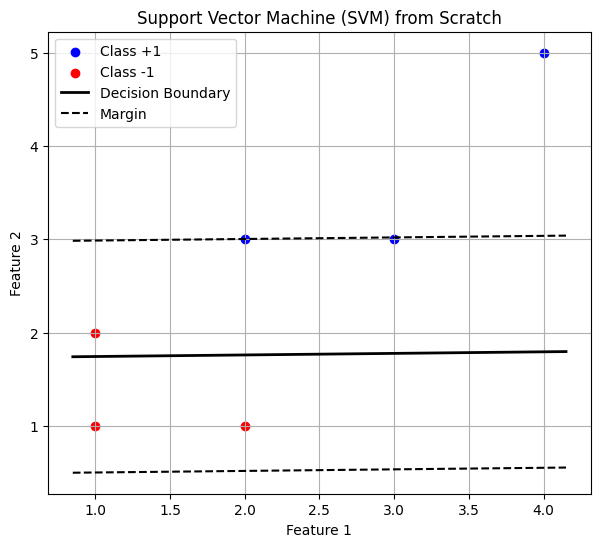

In [14]:
import matplotlib.pyplot as plt

# Plot the data points
plt.figure(figsize=(7,6))

# Positive class
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1],
            color='blue', label='Class +1')

# Negative class
plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1],
            color='red', label='Class -1')


# Decision boundary
ax = plt.gca()
x_values = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 100)

# Decision boundary: w.x + b = 0
y_values = -(model.weights[0] * x_values + model.bias) / model.weights[1]

# Margin lines: w.x + b = ±1
margin_positive = -(model.weights[0] * x_values + model.bias - 1) / model.weights[1]
margin_negative = -(model.weights[0] * x_values + model.bias + 1) / model.weights[1]

# Plot decision boundary
plt.plot(x_values, y_values,
         color='black',
         linewidth=2,
         label='Decision Boundary')

# Plot margins
plt.plot(x_values, margin_positive,
         'k--',
         label='Margin')

plt.plot(x_values, margin_negative,
         'k--')

# Labels
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Support Vector Machine (SVM) from Scratch")
plt.legend()
plt.grid(True)

plt.show()